# **Aplicación Práctica: Implementación con Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#libreria Scikit-Learn donde sacaremos el model SVM
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## **Carga del Dataset**

In [ ]:
print("Carga de Datos")
df = pd.read_csv("adult.csv")
df

Carga de Datos


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


## **Exploración de Datos**



In [ ]:
#reemplazamos los signos de interrogación por valores nulos (NaN)
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

print(f"Dimensiones del dataframe: {df.shape}")
print(f"Valores nulos por columna:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

#eliminar registros que contengan datos nulos
df = df.dropna()
print(f"Dimensiones después de limpiar nulos: {df.shape}")

#distribución de la variable objetivo
print("\nDistribución de la variable objetivo (Income):")
print(df['income'].value_counts(normalize=True) * 100)

Dimensiones del dataframe: (32561, 15)
Valores nulos por columna:
workclass         1836
occupation        1843
native.country     583
dtype: int64
Dimensiones después de limpiar nulos: (30162, 15)

Distribución de la variable objetivo (Income):
income
<=50K    75.107751
>50K     24.892249
Name: proportion, dtype: float64


## **Preprocesamiento de Datos**

In [ ]:
#transformar la variable objetivo a binaria (0 y 1)
y = df['income'].str.contains('>50K').astype(int)

#separar las características (X) de variable objetivo
X = df.drop(columns=['income'])

#One-Hot Encoding para variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)
print(f"Número de columnas tras One-Hot Encoding: {X_encoded.shape[1]}")

#division train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

#escalamiento de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos divididos y escalados correctamente.")

Número de columnas tras One-Hot Encoding: 96
Datos divididos y escalados correctamente.


## **Entrenamiento y ajuste de hiperparámetros**

In [ ]:
#submuestreo para gridsearch
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_scaled, y_train, train_size=5000, random_state=42, stratify=y_train
)

#modelo a utilizar
svm_base = SVC(random_state=42, class_weight='balanced') #class_weight ayuda con el desbalance de clases

#grid de hiperparámetros
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 0.1] # 'scale' es el valor por defecto basado en la varianza
}

print("Iniciando GridSearchCV en la submuestra de 5000 registros")
grid_search = GridSearchCV(svm_base, param_grid, refit=True, cv=3, verbose=1, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_sub, y_train_sub)

print(f"\nMejores hiperparámetros encontrados: {grid_search.best_params_}")

#training con todos los datos
print("Entrenando el modelo final con todos los datos de entrenamiento")
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_scaled, y_train)
print("Entrenamiento finalizado")

Iniciando GridSearchCV en la submuestra de 5000 registros
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Mejores hiperparámetros encontrados: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Entrenando el modelo final con todos los datos de entrenamiento
Entrenamiento finalizado


## **Análisis de Resultados y Métricas**

Accuracy en Test: 0.7855

Reporte de Clasificación:
              precision    recall  f1-score   support

       <=50K       0.94      0.76      0.84      4531
        >50K       0.54      0.86      0.67      1502

    accuracy                           0.79      6033
   macro avg       0.74      0.81      0.75      6033
weighted avg       0.84      0.79      0.80      6033



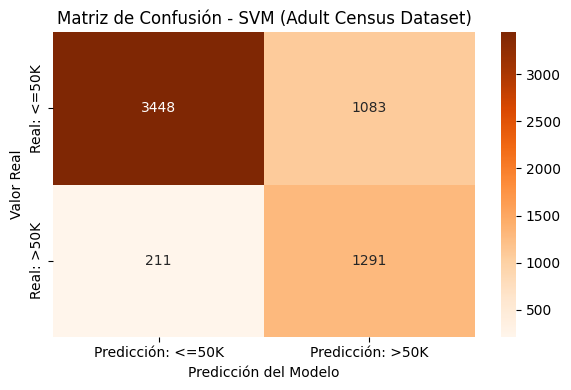

In [ ]:
#predicciones
y_pred = best_svm.predict(X_test_scaled)

#metricas
#accuracy
print(f"Accuracy en Test: {accuracy_score(y_test, y_pred):.4f}\n")

#precision, recall, f1score
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

#matriz de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predicción: <=50K', 'Predicción: >50K'],
            yticklabels=['Real: <=50K', 'Real: >50K'])
plt.title('Matriz de Confusión - SVM (Adult Census Dataset)')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.savefig('matriz_confusion_adult_svm.png')
plt.show()